In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torchmetrics import Accuracy, F1Score, AUROC, Precision, Recall
from HistoLib import pytorch_mil, pytorch_dataset, pytorch_model, utils


In [13]:
utils.dataset_description()


Total images 691
Total patients 45


,20x,40x,Total
aca_bd,57,46,103
aca_md,44,46,90
aca_pd,45,42,87
nor,85,66,151
scc_bd,50,49,99
scc_md,30,36,66
scc_pd,48,47,95
Total,359,332,691


## Get images

In [14]:
resolution = '20x'      # One of ['20x', '40x']
train_loader, val_loader, test_loader, class_names = pytorch_mil.get_mil_dataloaders(
    resolution=resolution,
    batch_size=3,
    image_scale=0.25, # Consistent with baseline
    reproducible=True # Use the splits from the original paper.
)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")
def show_batch(loader, title="Batch"):
    images, labels = next(iter(loader))
    plt.figure(figsize=(15, 6))
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)
        # Denormalize
        img = images[i][0].permute(1, 2, 0).numpy() # Take the first patch
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"Class: {class_names[labels[i].item()]}")
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


Number of training batches: 88
Number of validation batches: 16
Number of test batches: 16


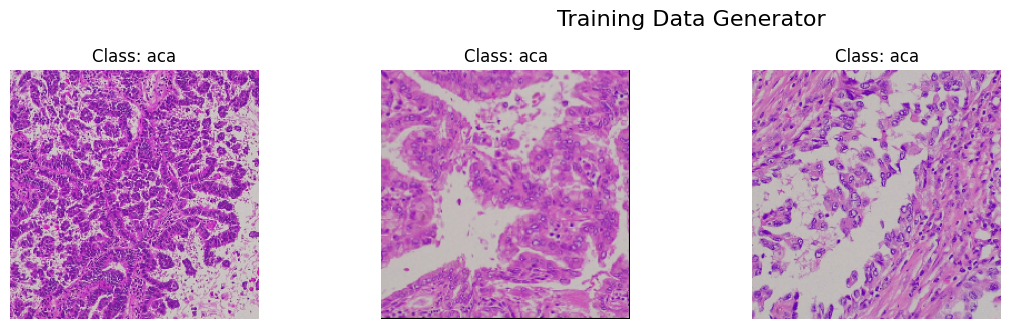

In [15]:
show_batch(train_loader, "Training Data Generator")


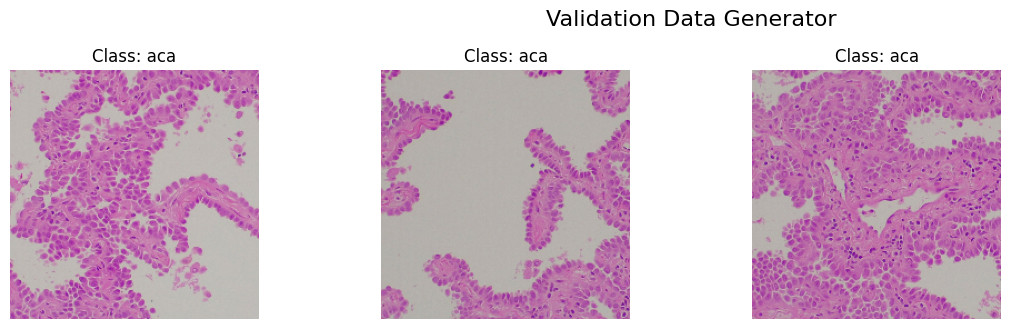

In [16]:
show_batch(val_loader, "Validation Data Generator")


## Train Model

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
num_classes = len(class_names)
model = pytorch_mil.MIL_ResNet50(num_classes=num_classes).to(device)


Using device: cuda


In [18]:
# Compute class weights
train_labels = train_loader.dataset.labels
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)
weights = total_samples / (num_classes * class_counts)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1)
metrics_collection = {
    'acc': Accuracy(task="multiclass", num_classes=num_classes).to(device),
    'f1': F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device),
    'auc': AUROC(task="multiclass", num_classes=num_classes).to(device),
    'precision': Precision(task="multiclass", num_classes=num_classes, average='macro').to(device),
    'recall': Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
}
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for m in metrics_collection.values(): m.reset()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        for m in metrics_collection.values(): m(outputs, labels)
        pbar.set_postfix({'loss': loss.item()})
        
    train_loss = running_loss / len(train_loader)
    train_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}
    
    model.eval()
    val_running_loss = 0.0
    for m in metrics_collection.values(): m.reset()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            for m in metrics_collection.values(): m(outputs, labels)
            
    val_loss = val_running_loss / len(val_loader)
    val_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Acc: {train_metrics['acc']:.4f} - Val Loss: {val_loss:.4f}, Acc: {val_metrics['acc']:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'mil_baseline_best.pth')


Epoch 1/10 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

/home/skattoju/code/LungHist700/.venv/lib64/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
/home/skattoju/code/LungHist700/.venv/lib64/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


Epoch 1/10 - Train Loss: 0.9659, Acc: 0.5171 - Val Loss: 0.9336, Acc: 0.5417


Epoch 2/10 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/10 - Train Loss: 0.6553, Acc: 0.7148 - Val Loss: 0.3761, Acc: 0.7917


...

Epoch 8/10 - Train Loss: 0.1562, Acc: 0.9430 - Val Loss: 0.6745, Acc: 0.8750


Epoch 9/10 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 9/10 - Train Loss: 0.1428, Acc: 0.9582 - Val Loss: 3.4129, Acc: 0.5208


Epoch 10/10 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.2131, Acc: 0.9163 - Val Loss: 1.1104, Acc: 0.7083


## Evaluate using test data

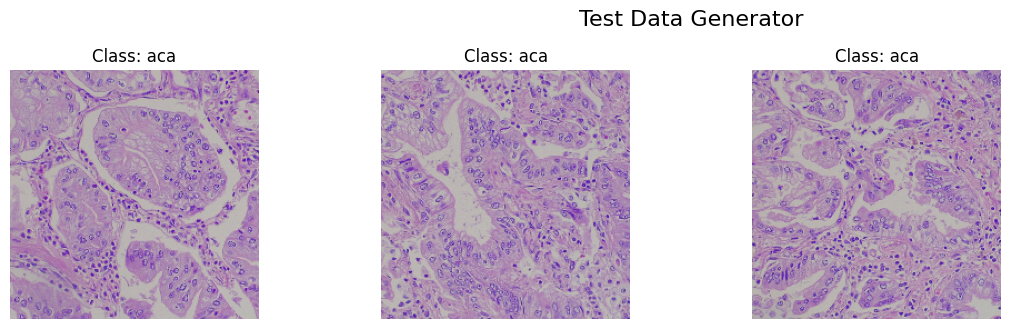

In [19]:
show_batch(test_loader, "Test Data Generator")


Test Loss: 0.2842
Test Accuracy: 0.9375
Test F1 Score: 0.9254
Test AUC: 0.9725
Test Precision (Macro): 0.9316
Test Recall (Macro): 0.9209


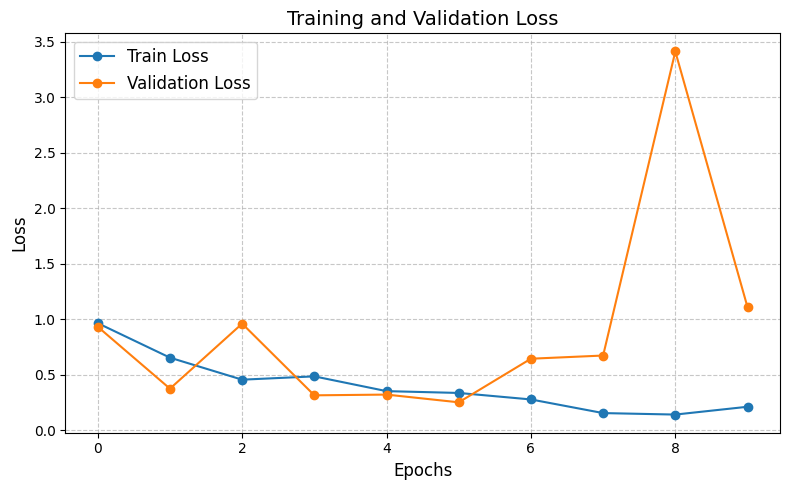

Saved mil_baseline_loss.png


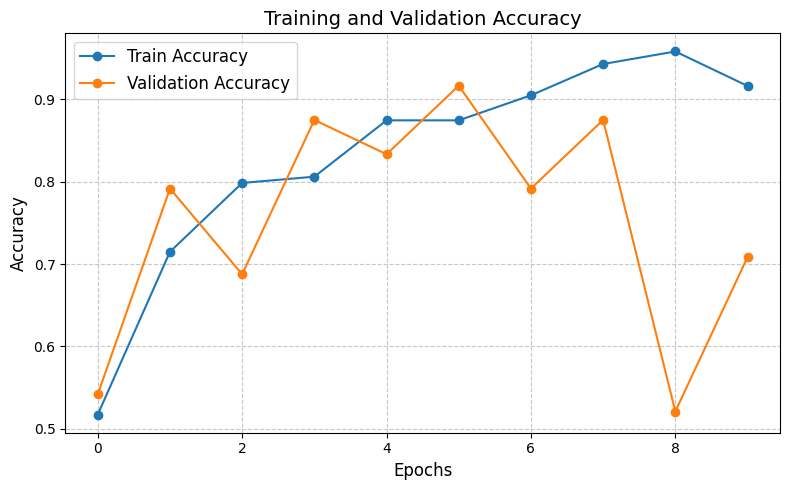

Saved mil_baseline_accuracy.png


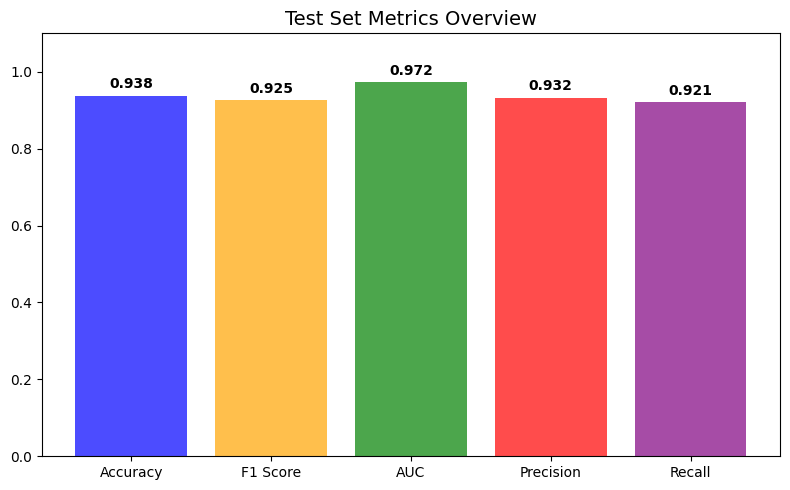

Saved mil_baseline_metrics.png


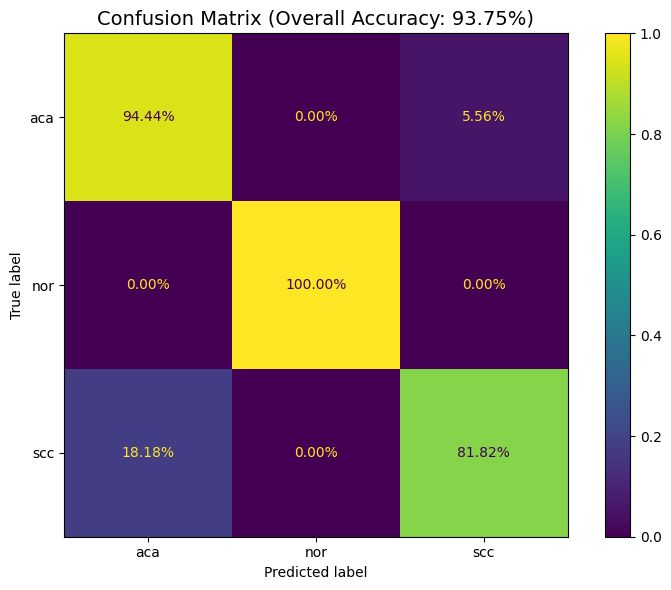

Saved mil_baseline_confusion_matrix.png


In [20]:
model.load_state_dict(torch.load("mil_baseline_best.pth"))
model.eval()
test_loss = 0.0
for m in metrics_collection.values(): m.reset()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        for m in metrics_collection.values(): m(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
test_loss /= len(test_loader)
test_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_metrics['acc']:.4f}")
print(f"Test F1 Score: {test_metrics['f1']:.4f}")
print(f"Test AUC: {test_metrics['auc']:.4f}")
print(f"Test Precision (Macro): {test_metrics['precision']:.4f}")
print(f"Test Recall (Macro): {test_metrics['recall']:.4f}")
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# --- Plot 1: Training Loss ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history['train_loss'], label='Train Loss', marker='o')
ax.plot(history['val_loss'], label='Validation Loss', marker='o')
ax.set_title('Training and Validation Loss', fontsize=14)
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('mil_baseline_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved mil_baseline_loss.png")

# --- Plot 2: Training Accuracy ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax.plot(history['val_acc'], label='Validation Accuracy', marker='o')
ax.set_title('Training and Validation Accuracy', fontsize=14)
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('mil_baseline_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved mil_baseline_accuracy.png")



# --- Plot 3: Training AUC ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history['train_auc'], label='Train AUC', marker='o')
ax.plot(history['val_auc'], label='Validation AUC', marker='o')
ax.set_title('Training and Validation AUC', fontsize=14)
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('mil_baseline_auc.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved mil_baseline_auc.png")


# --- Plot 4: Training AUC ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history['train_auc'], label='Train AUC', marker='o')
ax.plot(history['val_auc'], label='Validation AUC', marker='o')
ax.set_title('Training and Validation AUC', fontsize=14)
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('mil_baseline_auc.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved mil_baseline_auc.png")


# --- Plot 5: Confusion Matrix (normalized, showing per-class accuracy) ---
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds,
    display_labels=class_names,
    normalize='true',
    values_format='.2%',
    ax=ax
)
ax.set_title(f"Confusion Matrix (Overall Accuracy: {test_metrics['acc']:.2%})", fontsize=14)
plt.tight_layout()
plt.savefig('mil_baseline_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved mil_baseline_confusion_matrix.png")


Generating MIL Attention Visualization samples...
Saved mil_attention_viz.png


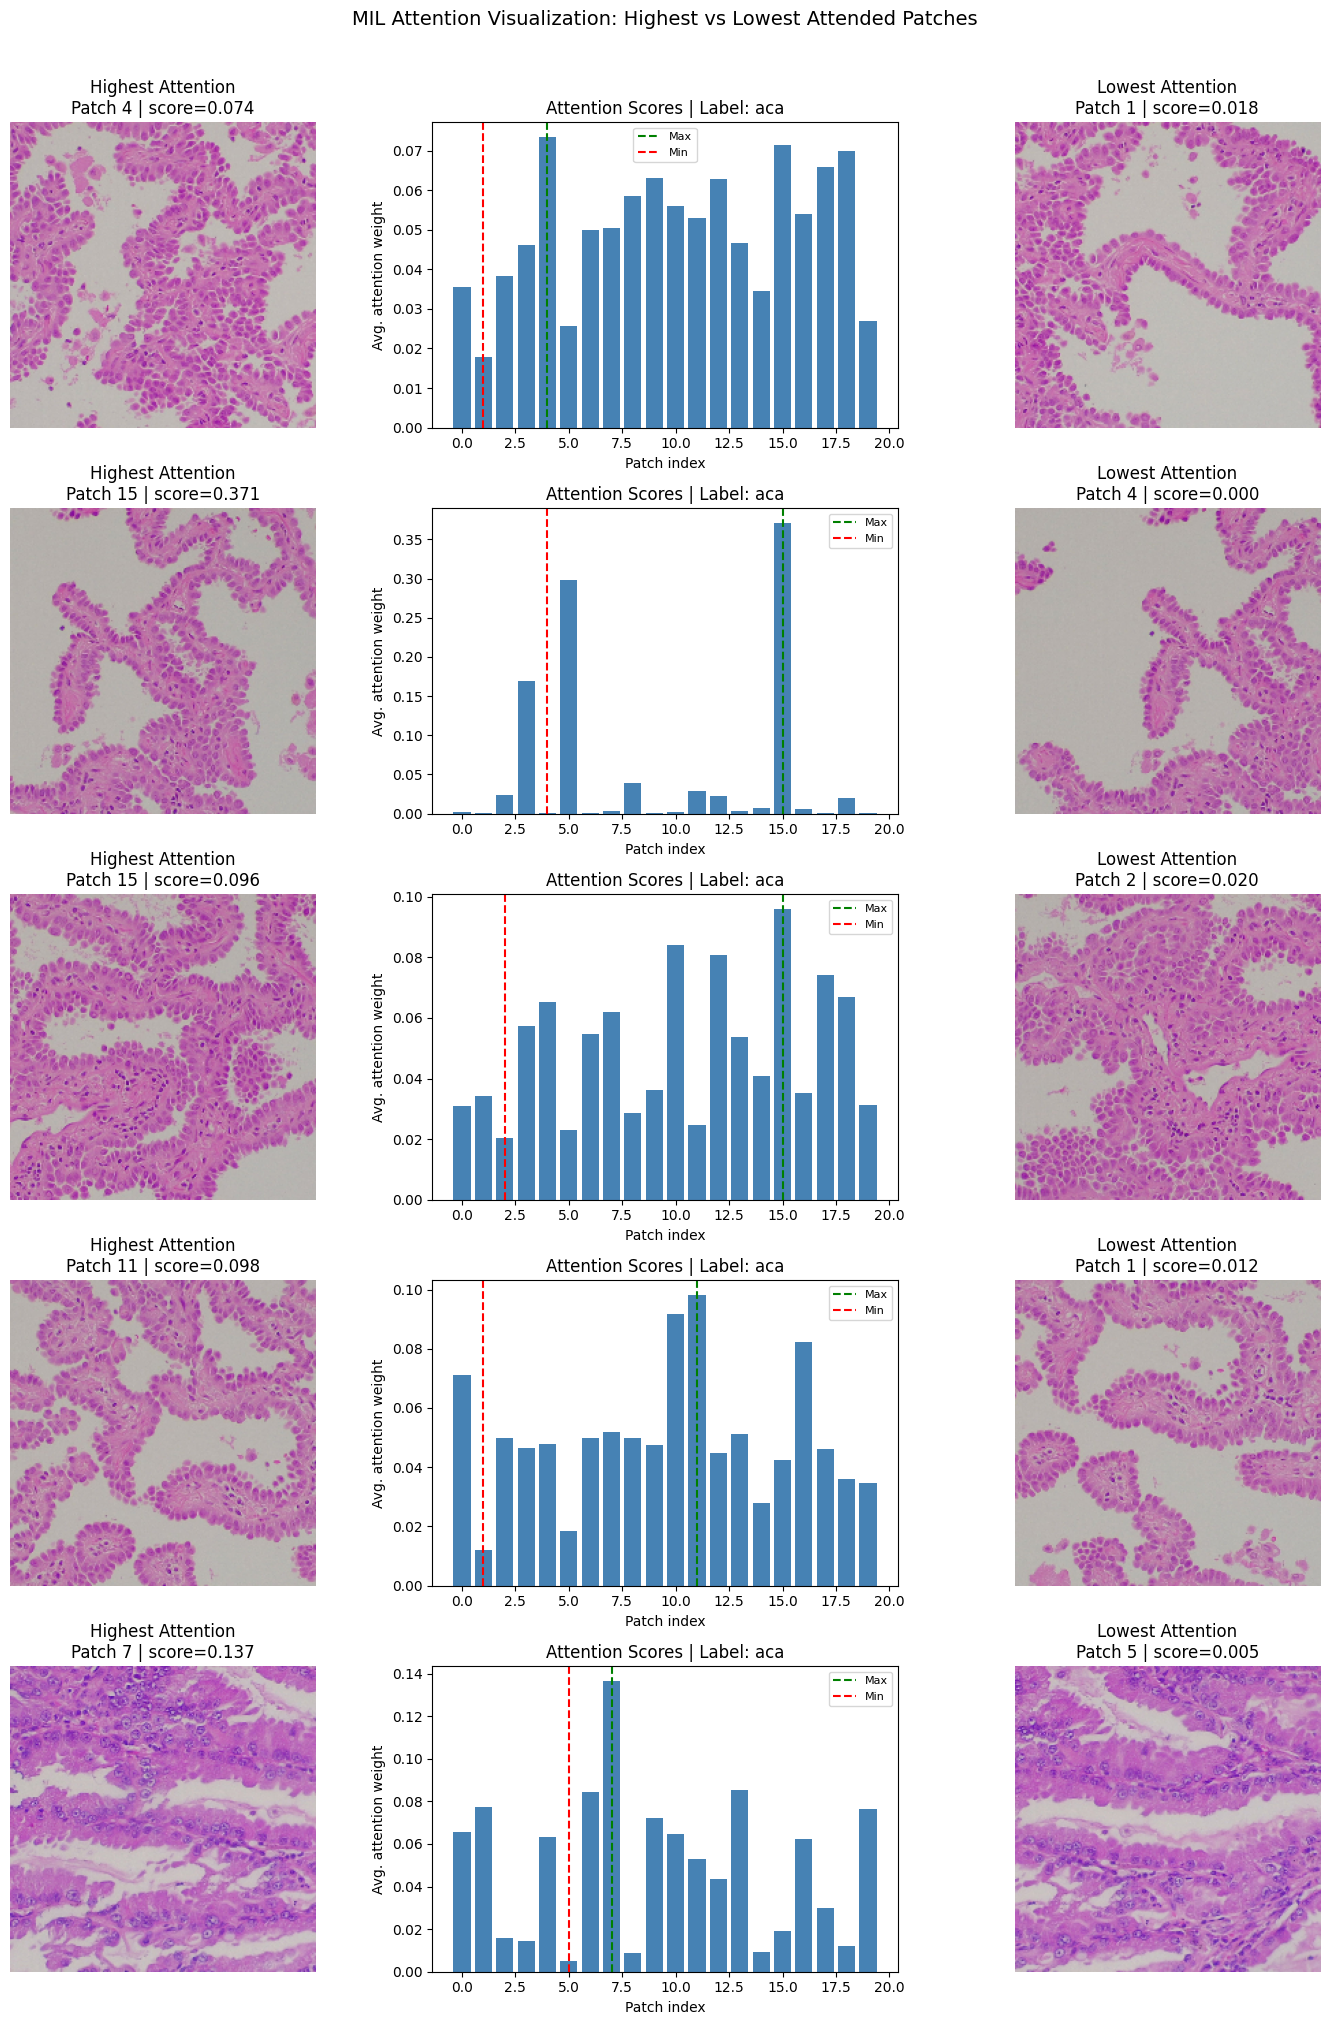

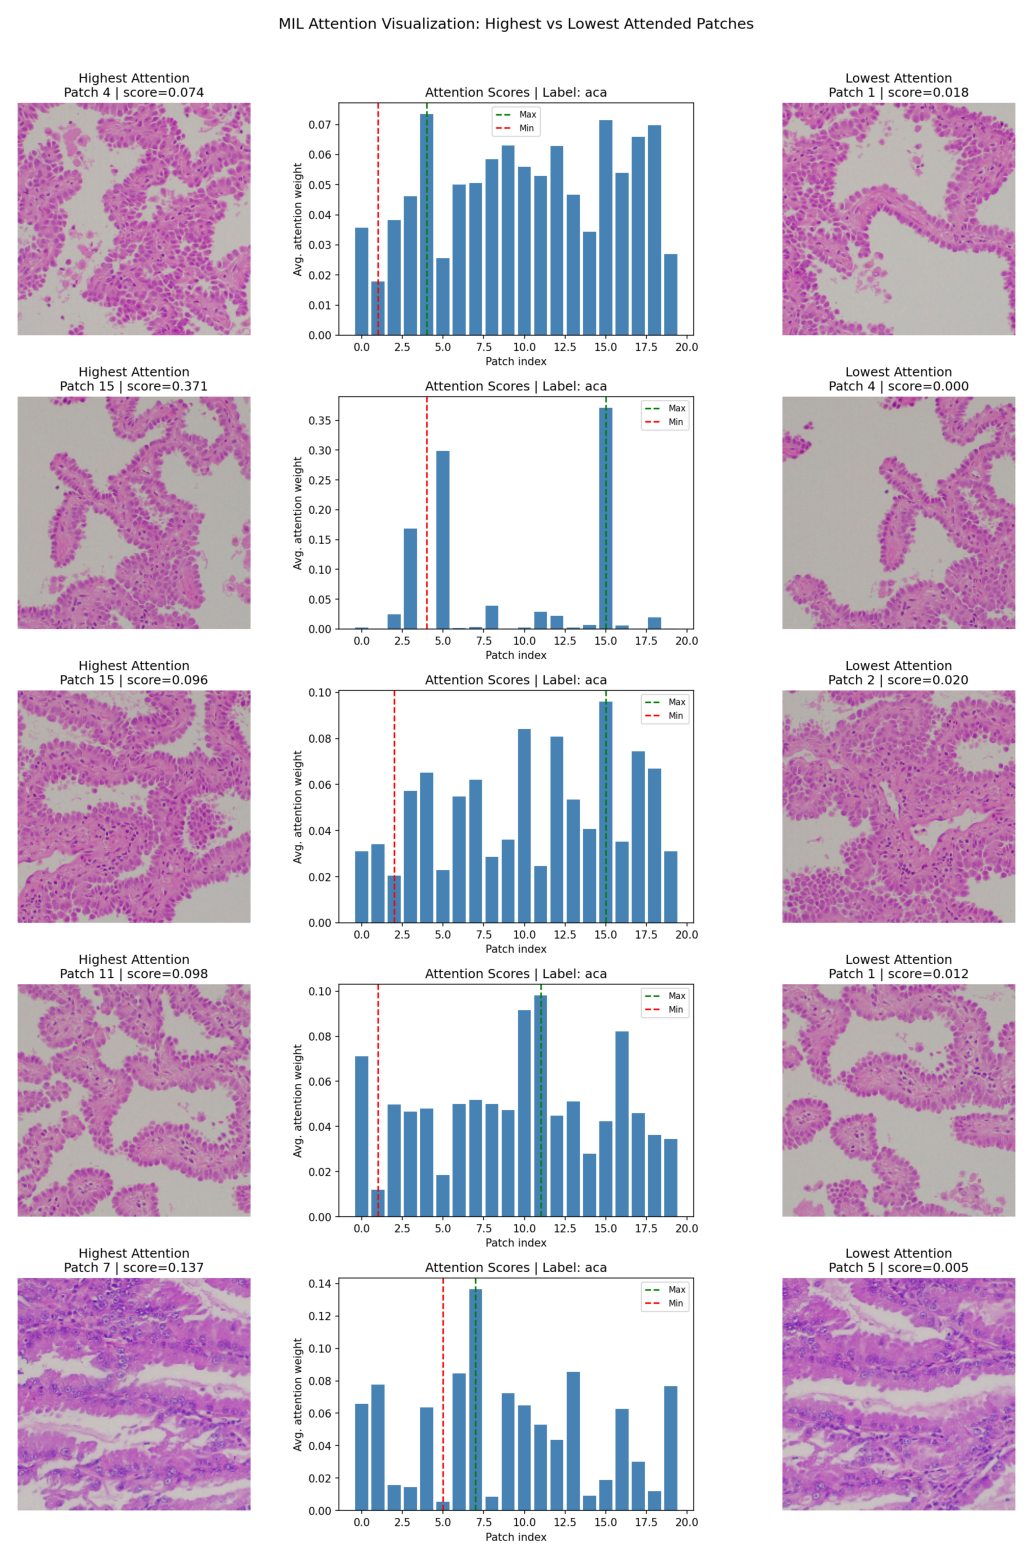

In [21]:
print("Generating MIL Attention Visualization samples...")
model.eval()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

num_samples = 5
images_shown = 0
fig, axs = plt.subplots(num_samples, 3, figsize=(15, num_samples * 4))

for bags, labels in val_loader:
    bags = bags.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        B, N, C, H, W = bags.shape
        bags_flat = bags.view(B * N, C, H, W)
        features = model.backbone(bags_flat).view(B, N, model.embed_dim)
        _, attn_weights = model.attention(features, features, features, average_attn_weights=True)
        patch_importance = attn_weights.mean(dim=1)  # [B, N]

    for b in range(B):
        if images_shown >= num_samples:
            break
        label_idx = labels[b].item()
        importance = patch_importance[b].cpu().numpy()
        top_idx = int(importance.argmax())
        bot_idx = int(importance.argmin())

        def denorm(t):
            img = t.cpu().numpy().transpose(1, 2, 0)
            return np.clip(std * img + mean, 0, 1)

        row = images_shown
        axs[row, 0].imshow(denorm(bags[b, top_idx]))
        axs[row, 0].set_title(f"Highest Attention\nPatch {top_idx} | score={importance[top_idx]:.3f}")
        axs[row, 0].axis("off")

        axs[row, 1].bar(range(N), importance, color="steelblue")
        axs[row, 1].axvline(top_idx, color="green", linestyle="--", label="Max")
        axs[row, 1].axvline(bot_idx, color="red",   linestyle="--", label="Min")
        axs[row, 1].set_title(f"Attention Scores | Label: {class_names[label_idx]}")
        axs[row, 1].set_xlabel("Patch index")
        axs[row, 1].set_ylabel("Avg. attention weight")
        axs[row, 1].legend(fontsize=8)

        axs[row, 2].imshow(denorm(bags[b, bot_idx]))
        axs[row, 2].set_title(f"Lowest Attention\nPatch {bot_idx} | score={importance[bot_idx]:.3f}")
        axs[row, 2].axis("off")

        images_shown += 1

    if images_shown >= num_samples:
        break

plt.suptitle("MIL Attention Visualization: Highest vs Lowest Attended Patches", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("mil_attention_viz.png", dpi=150, bbox_inches="tight")
print("Saved mil_attention_viz.png")
import matplotlib.image as mpimg
img = mpimg.imread("mil_attention_viz.png")
plt.figure(figsize=(18, num_samples * 4))
plt.imshow(img)
plt.axis("off")
plt.show()